# Fitting matrices

**This notebook shows how you can fit your function to predict matrices for configurations**. We create the target matrices synthetically.

<div class="alert alert-info">

Note

This tutorial shows the rawest possible training workflow. Notice that we provide tools to easily perform training with ``pytorch_lightning`` (including a CLI). Look for "Lightning" in the API documentation to understand the tools that we provide, or go to the CLI tutorials to understand how train with the CLI.

</div>

Prerequisites
-------------

Before reading this notebook, **make sure you have read the [notebook on computing a matrix](<./Computing a matrix.ipynb>) and [the notebook on batching](./Batching.ipynb)**, which introduce the basic concepts of `graph2mat` that we are going to assume are already known. Also **we will use exactly the same setup as in the batching notebook**, with the only difference that we will compute add target matrices to each structure.

In this notebook we will:

- Introduce the **addition of a target matrix** to a configuration.
- **Introduce the metrics** that can be used as loss functions.
- **Introduce the simplest training loop**.

It is **specially useful if you are quite new to machine learning**, because it goes step by step. It also serves as a minimal example from which you can expand to create training flows different from the ones we propose.

In [1]:
import os
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"

In [2]:
import numpy as np
import pandas as pd
import torch

# To load plotly templates for sisl visualization
import sisl.viz

from e3nn import o3

from graph2mat import (
    BasisConfiguration,
    PointBasis,
    BasisTableWithEdges,
    MatrixDataProcessor,
)
from graph2mat.bindings.torch import TorchBasisMatrixDataset, TorchBasisMatrixData

from graph2mat.bindings.e3nn import E3nnGraph2Mat

from graph2mat.tools.viz import plot_basis_matrix

from torch_geometric.loader import DataLoader
from graph2mat.models import MatrixMACE

/home/saru/anaconda3/envs/basisc/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


Setting up the model
--------------------

We will fit a TZP water. This means:
Triple zeta polarized.

- For H we have: 3s + 1p  (size: 3x1 + 3 = 6)
- For O we have: 3s + 3p + 1d  (size: 3x1 + 3x3 + 1x5 = 17)

Min sizes are:
- For H: 1s : 1
- For O: 1s + 1p : 1 + 3 = 4

As usual, let's create our model:

# Define basis and configuration

In [3]:
# The basis
point_1r = PointBasis("H", R=5, basis="3x0e + 1o", basis_convention="spherical", matrix_role="col")
point_1c = PointBasis("H", R=5, basis="0e", basis_convention="spherical", matrix_role="row")  # minimum size
point_2r = PointBasis("O", R=5, basis="3x0e + 3x1o + 2e", basis_convention="spherical", matrix_role="col")
point_2c = PointBasis("O", R=5, basis="0e + 1o", basis_convention="spherical", matrix_role="row")  # minimum size


basis = [point_1r, point_1c, point_2r, point_2c]

# The basis table.
table = BasisTableWithEdges(basis)

# The data processor.
processor = MatrixDataProcessor(
    basis_table=table, symmetric_matrix=False, sub_point_matrix=False
)
array_pos_from_siesta = """5.00000000  5.00000000  0.11926200 1 # 1: O
5.00000000  5.76323900 -0.47704700 2 # 2: H
5.00000000  4.33683900 -0.47704700 2 # 3: H"""
positions = np.zeros((3, 3))
for i in range(3):
    line = array_pos_from_siesta.splitlines()[i]
    x, y, z, _ = line.split()[:4]
    positions[i] = [float(x), float(y), float(z)]



config = BasisConfiguration(
    point_types=["O", "H", "H"],
    positions=positions,
    basis=basis,
    cell=np.eye(3) * 100,
    pbc=(False, False, False))


# Create the dataset
dataset = TorchBasisMatrixDataset([config], data_processor=processor)
loader = DataLoader(dataset, batch_size=1)

data = next(iter(loader))

Defined col for type H with basis ((3, 0, 1), (1, 1, -1)) and reach 5.
Defined row for type H with basis ((1, 0, 1),) and reach 5.
Defined col for type O with basis ((3, 0, 1), (3, 1, -1), (1, 2, 1)) and reach 5.
Defined row for type O with basis ((1, 0, 1), (1, 1, -1)) and reach 5.


# Create the MACE model

In [4]:
from mace.modules import MACE, RealAgnosticResidualInteractionBlock

num_interactions = 3
hidden_irreps = o3.Irreps("1x0e + 1x1o")

mace_model = MACE(
    r_max=10,
    num_bessel=10,
    num_polynomial_cutoff=10,
    max_ell=2,  # 1,
    interaction_cls=RealAgnosticResidualInteractionBlock,
    interaction_cls_first=RealAgnosticResidualInteractionBlock,
    num_interactions=num_interactions,
    num_elements=2,
    hidden_irreps=hidden_irreps,
    MLP_irreps=o3.Irreps("2x0e"),
    atomic_energies=torch.tensor([0, 0]),
    avg_num_neighbors=2,
    atomic_numbers=[0, 1],
    correlation=2,
    gate=None,
)

/home/saru/anaconda3/envs/basisc/lib/python3.10/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/saru/anaconda3/envs/basisc/lib/python3.10/site-packages/mace/modules/blocks.py:312: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(atomic_energies, dtype=torch.get_default_dtype()),
/home/saru/anaconda3/envs/basisc/lib/python3.10/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.

# Define the graph2mat
Using the MACE model architecture.

In [5]:
mace_out_irreps = hidden_irreps * (num_interactions - 1) + str(hidden_irreps[0])

# # The matrix readout function
# model = E3nnGraph2Mat(
#     unique_basis=basis,
#     irreps=dict(node_feats_irreps=mace_out_irreps),
#     symmetric=False,
#     preprocessing_edges=None,
# )
matrix_mace_model = MatrixMACE(
    mace_model,
    unique_basis=table,
    readout_per_interaction=True,
    edge_hidden_irreps=o3.Irreps("10x0e + 10x1o + 10x2e"),
    symmetric=False,
)

/home/saru/anaconda3/envs/basisc/lib/python3.10/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/saru/anaconda3/envs/basisc/lib/python3.10/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/saru/anaconda3/envs/basisc/lib/python3.10/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/

# Filll the matrix with the MACE first guess

In [6]:

mace_output = matrix_mace_model(data)
# We cannot fill with a stating nonsuare matrix.. so ill try a goaround
matrix = processor.matrix_from_data(
    data,
    predictions=mace_output,
)


During training, we will compare these to the output of `Graph2Mat`.

We can also plot the target matrices from the data example:

In [7]:
def plot_matrices(data, config, predictions=None, title="", show=True):
    """Helper function to plot (possibly batched) matrices"""

    matrices = processor.matrix_from_data(data, predictions=predictions)

    if not isinstance(matrices, (tuple, list)):
        matrices = (matrices,)

    for i, (config, matrix) in enumerate(zip(config, matrices)):
        if show is True or show == i:
            plot_basis_matrix(
                matrix,
                config,
                point_lines={"color": "black"},
                basis_lines={"color": "blue"},
                colorscale="temps",
                text=".2f",
                basis_labels=True,
            ).update_layout(title=f"{title} [{i}]").show()


plot_matrices(data, [config],
              predictions={"node_labels": mace_output["node_labels"],
                           "edge_labels": mace_output["edge_labels"]},
            title="Labels")

The simplest training loop
--------------------------

Below we just create a simple `pytorch` training loop that:

1. Uses the model to **compute predictions** for the matrix
2. **Computes the loss** (error).
3. Computes the gradients and **updates the model parameters**.
4. **Goes back** to 1.

While doing so we store the errors at each step so that we can plot their evolution later.

There is just one last thing that we need to introduce: `graph2mat`'s metrics. The `metrics` module contains several functions that compare matrices in different ways. They can be used as loss functions. In this case, we will use `elementwise_mse`, which just computes the [Mean Squared Error](https://en.wikipedia.org/wiki/Mean_squared_error) of all the matrix elements.

In [8]:
import warnings


def loss_contract(matrices, dms):
    # print("shapes of matrices:", [C.shape for C in matrices])

    CCts = [C.T @ C for C in matrices]
    for CCt in CCts:
        if not isinstance(CCt, torch.Tensor):
            raise ValueError(f"CCt is not a torch.Tensor, but {type(CCt)}")

    # print("shapes of CCts:", [CCt.shape for CCt in CCts])
    
    # print("shapes of dms:", [dm.shape for dm in dms])

    errs = [(CCt @ dm) - dm for CCt, dm in zip(CCts, dms)]
    return sum((err**2).mean() for err in errs)


CACHE = {}

def get_dms_ref(paths_ref, dtype):
    """
    Get the density matrices for a list of reference structure paths.

    If this is the first time this function is called for the given paths,
    it reads the data from disk and computes the density matrices.
    The results are cached for future calls.

    Parameters
    ----------
    paths_ref :
        A list of paths to the reference structure files.
    dtype :
        The desired torch dtype.
    Returns
    -------
    list of torch.Tensor
        A list of density matrices corresponding to the reference structures.
    """
    
    dms = []
    dms = []
    for struct_path in paths_ref:
        _, _, vecs, _= get_H_S_occ_eigvecs(struct_path, dtype=dtype)
        dm = vecs @ vecs.T
        dms.append(dm)

    return dms

def get_H_S_occ_eigvecs(path, dtype):
    """
    Get the Hamiltonian, overlap matrix, occupied eigenvectors and eigenvalues
    for a given structure path.

    If this is the first time this function is called for the given path,
    it reads the data from disk and computes the occupied eigenvectors and eigenvalues.
    The results are cached for future calls.
    
    Parameters
    ----------
    path :
        The path to the structure file.
    dtype :
        The desired torch dtype.
    device :
        The desired torch device. 
    """

    if path in CACHE:
        return CACHE[path]
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        H = sisl.get_sile(path).read_hamiltonian()
        S = sisl.get_sile(path).read_overlap()

    if isinstance(dtype, np.dtype):
        dtype = torch.from_numpy(np.empty(0, dtype=dtype)).dtype

    eigstate = H.eigenstate()
    mask = eigstate.eig < 0  # Only consider occupied states
    vecs = eigstate.state[mask, :].T  # Only consider occupied states

    eigvals = torch.tensor(eigstate.eig[mask], dtype=dtype)
    vecs = torch.tensor(vecs, dtype=dtype)

    H = torch.tensor(H.tocsr().todense(), dtype=dtype)
    S = torch.tensor(S.tocsr().todense(), dtype=dtype)

    CACHE[path] = (H, S, vecs, eigvals)

    return H, S, vecs, eigvals

In [9]:
path_ref = 'ref_data/H2O_TZP/RUN.fdf'

dms_ref = get_dms_ref([path_ref], dtype=matrix[0].dtype)


In [10]:
n_steps = 5

In [ ]:
# Create the data loader
from torch_geometric.loader import DataLoader
from scipy.sparse import save_npz, csr_matrix
from matplotlib import pyplot as plt

loader = DataLoader(dataset)

# Number of training steps

# Initialize an optimizer
optimizer = torch.optim.Adam(
    list(matrix_mace_model.parameters()))

# Initialize arrays to store errors
losses = np.zeros(n_steps)
node_rmse = np.zeros(n_steps)
edge_rmse = np.zeros(n_steps)

# The loss function, which we get from graph2mat's metrics functions
from graph2mat import metrics

torch.autograd.set_detect_anomaly(True)
# Loop
for i in range(n_steps):
    for data in loader:
        # Reset gradients
        optimizer.zero_grad()
        # with torch.no_grad(): # SN: lo he añadido yo
        #     mace_output = mace_model(data)
        mace_output = matrix_mace_model(data)

        # We cannot fill with a stating nonsuare matrix.. so ill try a goaround
        matrix = processor.matrix_from_data(
            data,
            predictions=mace_output,
            out_format="torch"
        )

        # Compute the loss
        loss = loss_contract(
            matrices=matrix,  dms=dms_ref
        )

        # Store errors
        losses[i] = loss
        print(f"Step {i}: Loss = {loss.item():.6f}")

        # Compute gradients
        loss.backward()

        # Update weights
        optimizer.step()


final_matrix = processor.matrix_from_data(
            data,
            predictions=mace_output,
        )

# save matrix
save_path = f"outputs/mat_H2O_TZP_{n_steps}steps.npz"
save_npz(save_path, final_matrix[0])
# save loss
np.save(f"outputs/loss_H2O_TZP_{n_steps}steps.npy", losses)
# save node and edge labels
save_path_node_labels = f"outputs/node_labels_H2O_TZP_{n_steps}steps"
save_path_edge_labels = f"outputs/edge_labels_H2O_TZP_{n_steps}steps"
final_node_labels = mace_output["node_labels"].detach().cpu()
final_edge_labels = mace_output["edge_labels"].detach().cpu()
np.save(save_path_node_labels, mace_output["node_labels"].detach().cpu().numpy())
np.save(save_path_edge_labels, mace_output["edge_labels"].detach().cpu().numpy())

/tmp/ipykernel_40179/3195844884.py:45: UserWarning:

Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)



Step 0: Loss = 0.001730
Step 1: Loss = 0.001730
Step 2: Loss = 0.001730
Step 3: Loss = 0.001730
Step 4: Loss = 0.001730


NameError: name 'final_matrix' is not defined

In [ ]:
from matplotlib import pyplot as plt
losses = np.load(f"outputs/loss_H2O_TZP_{n_steps}steps.npy")
plt.plot(losses)
plt.yscale("log")
plt.ylabel("Loss")
plt.xlabel("Training Step")


In [ ]:
# load it to comprobe i can
from scipy.sparse import load_npz
save_path = f"outputs/mat_H2O_TZP_{n_steps}steps.npz"
final_matrix = load_npz(save_path)
print("Loaded matrix type:", type(final_matrix))
final_node_labels = np.load(f"outputs/node_labels_H2O_TZP_{n_steps}steps.npy")
final_edge_labels = np.load(f"outputs/edge_labels_H2O_TZP_{n_steps}steps.npy")
print("Loaded node labels type:", type(final_node_labels))
print("Loaded edge labels type:", type(final_edge_labels))


Loaded matrix type: <class 'scipy.sparse._csr.csr_array'>
Loaded node labels type: <class 'numpy.ndarray'>
Loaded edge labels type: <class 'numpy.ndarray'>


And plot them:

The model has learned something, but still the errors are quite high.

We can plot the first target matrix and the corresponding prediction:

In [ ]:
# convert final_node_labels and final_edge_labels to torch tensors
final_node_labels = torch.tensor(final_node_labels)
final_edge_labels = torch.tensor(final_edge_labels)

In [ ]:
plot_matrices(data, [config],
              predictions={"node_labels": final_node_labels, "edge_labels": final_edge_labels},
            title=f"Prediction after 500 training steps", show=True)

In [ ]:
# Save the matrix to siesta ACOEFFS format

In [ ]:
import struct
def csr_to_siesta(csr):
    """
    Convert a SciPy CSR matrix directly to SIESTA sparse format.
    
    Parameters
    ----------
    csr : scipy.sparse.csr_matrix
        The sparse matrix in CSR format.

    Returns
    -------
    numd : np.ndarray of int32, shape (n,)
        Number of non-zero entries per row.
    listd : np.ndarray of int32, shape (nnz,)
        Column indices (1‑based) row by row.
    dm    : np.ndarray of float64, shape (nnz,)
        Matrix values in the same order as listd.
    """
    numd = np.diff(csr.indptr).astype(np.int32)   # indptr -> number of entries per row
    listd = (csr.indices + 1).astype(np.int32)    # 0-based -> 1-based columns
    dm = csr.data.astype(np.float64)
    return numd, listd, dm


def __write_CSC_matrix(fname, numd, listd, matrix, is_formatted=False):
    """
    Python version of write_CSC_matrix.
    Args:
        fname : str
            Output filename.
        numd : array_like of int, shape (nb,)
            Number of non-zero elements per row (≥1, diagonal included).
        listd : array_like of int, shape (total_nnz,)
            Column indices, i.e., in which column the non-zero elements are located, in the same order as dm.
            It is flattened.
        dm : array_like of float, shape (total_nnz, nspin)
            Density matrix values in the same order as listd.
        is_formatted : bool, optional
            If True, write formatted (ASCII) file; otherwise binary (default).
    """
    nb = len(numd)                     # number of rows (basis orbitals)
    total_nnz = np.sum(numd)           # total non‑zeros

    # Sanity checks
    assert len(listd) == total_nnz, "listd length does not match sum(numd)"
    assert  matrix.shape == (total_nnz, ), "dm shape mismatch"

    if is_formatted:
        # Formatted (text) output – rows are on separate lines
        with open(fname, 'w') as f:
            # Header line
            f.write(f"{nb:11d}{1:11d}\n")

            # Write numd (all on one line, but Fortran may split; any whitespace is fine)
            f.write(' '.join(str(x) for x in numd) + '\n')

            # Write listd row by row
            idx = 0
            for row in range(nb):
                row_nnz = numd[row]
                row_listd = listd[idx:idx+row_nnz]
                f.write(' '.join(str(x) for x in row_listd) + '\n')
                idx += row_nnz

            # Write matrix values: each row, one line
            idx = 0
            for row in range(nb):
                row_nnz = numd[row]
                row_vals = matrix[idx:idx+row_nnz]
                f.write(' '.join(f"{v:22.14E}" for v in row_vals) + '\n')
                idx += row_nnz

    else:
        # Binary – exact Fortran unformatted record layout
        with open(fname, 'wb') as f:
            # Helper to write a Fortran record
            def write_record(data):
                """Write a Fortran unformatted record: [length][data][length]"""
                # Ensure data is a contiguous array of the correct type
                data = np.asarray(data)
                length = data.nbytes
                f.write(struct.pack('i', length))   # leading marker
                data.tofile(f)                      # raw data
                f.write(struct.pack('i', length))   # trailing marker

            # Record 1: nb, nspin=1 (as we dont have spin as this is not a dm)
            write_record(np.array([nb, 1], dtype=np.int32))

            # Record 2: full numd array
            write_record(numd)

            # Records 3..(2+nb): listd, one row per record
            idx = 0
            for row in range(nb):
                row_nnz = numd[row]
                row_listd = listd[idx:idx+row_nnz]
                write_record(row_listd)
                idx += row_nnz

            # Records for matrix values: for each row, one record
            idx = 0
            for row in range(nb):
                row_nnz = numd[row]
                row_vals = matrix[idx:idx+row_nnz]
                write_record(row_vals)
                idx += row_nnz

In [ ]:
# save my matrix in siesta format
numd, listd, dm = csr_to_siesta(final_matrix)
__write_CSC_matrix(f"outputs/mat_H2O_TZP_{n_steps}steps.A_COEFFS", numd, listd, dm, is_formatted=False)

In [ ]:
import warnings
from scipy.sparse import csr_matrix
def __lowdin_orthogonalization(S, eps=1e-10, inverse=False):
    """
    Compute S^{+1/2} or S^{-1/2} using Löwdin orthogonalization.

    The Löwdin orthogonalization is given by:
    S^{1/2} = U Λ^{1/2} U^T
    or
    S^{-1/2} = U Λ^{-1/2} U^T
    where S = U Λ U^T is the eigen-decomposition of S.

    Parameters
    ----------
    S : (N, N) ndarray
        Symmetric overlap matrix
    eps : float
        Eigenvalue cutoff for numerical stability

    Returns
    -------
    S_sqrt : (N, N) ndarray
        S^{1/2} if inverse is False or S^{-1/2} if inverse is True
    """
    # Diagonalize S
    eigvals, eigvecs = np.linalg.eigh(S)

    # Remove near-zero eigenvalues (optional but recommended)
    mask = eigvals > eps
    eigvals = eigvals[mask]
    eigvecs = eigvecs[:, mask]
    if inverse:
        # Construct Λ^{-1/2}
        Lambda_sqrt = np.diag(1.0 / np.sqrt(eigvals))
    else:
        # Construct Λ^{1/2}
        Lambda_sqrt = np.diag(np.sqrt(eigvals))

    # Reconstruct S^{1/2} or S^{-1/2}
    S_sqrt = eigvecs @ Lambda_sqrt @ eigvecs.T

    return S_sqrt

def __construct_s1c(S, primitive_sizes, eps=1e-10, inverse=False):
    """
    Construct the block diagonal matrix s_1c using Löwdin orthogonalization
    on each block of the overlap matrix S.

    Parameters
    ----------
    S : (N, N) sparse matrix or ndarray
        Overlap matrix
    primitive_sizes : list of int
        Sizes of each block corresponding to primitive basis functions
    eps : float
        Eigenvalue cutoff for numerical stability
    inverse : bool
        If True, compute S^{-1/2} for each block; otherwise compute S^{1/2}

    Returns
    -------
    s_1c : (N, N) ndarray
        Block diagonal matrix with Löwdin orthogonalized blocks
    """
    s_1c = np.zeros_like(S)
    i = 0

    for size in primitive_sizes:
        S_block = S[i:i+size, i:i+size]
        if isinstance(S_block, csr_matrix):
            print("Converting sparse block to dense array for Löwdin orthogonalization.")
            S_block = S_block.toarray()
        if size == 1:
            if inverse:
                S1c_block = np.array([[1.0 / np.sqrt(S_block[0, 0])]])
            else:
                S1c_block = np.array([[np.sqrt(S_block[0, 0])]])
        else:
            S1c_block = __lowdin_orthogonalization(S_block, eps=eps, inverse=inverse)
        s_1c[i:i+size, i:i+size] = S1c_block
        i += size
    return s_1c


def __diagonalize_atomwise(M, primitive_sizes):
    """
    Diagonalize each block of the matrix M atomwise.

    The atomic orbitals corresponding to each atom are specified by the
    primitive_sizes list.

    Parameters
    ----------
    M : (N, N) ndarray
        Matrix to be diagonalized blockwise
    primitive_sizes : list of int
        Sizes of each block corresponding to primitive basis functions
    Returns
    -------
    M_block_diag_eigvals : (N, N) ndarray
        Block diagonal matrix with eigenvalues on each block
    M_block_diag_eigvecs : (N, N) ndarray
        Block diagonal matrix with eigenvectors on each block
    """
    M_block_diag_eigvals = np.zeros_like(M)
    M_block_diag_eigvecs = np.zeros_like(M)
    i = 0
    for size in primitive_sizes:
        M_block = M[i:i+size, i:i+size]
        eigvals, eigvecs = np.linalg.eigh(M_block)
        M_block_diag_eigvals[i:i+size, i:i+size] = np.diag(eigvals)
        M_block_diag_eigvecs[i:i+size, i:i+size] = eigvecs
        i += size
    return M_block_diag_eigvals, M_block_diag_eigvecs



def get_optimal_atomwise_contraction(fdf, tol=10, contractions_per_atom=None, verbose=False):
    """
    Get the optimal atomwise contraction from a given FDF file.
    

    TODO: optimize this: one can obtain blockwise the contraction matrix and pass it to csc format from there.
    Parameters
    ----------
    fdf : str
        Path to the FDF file
    tol : float
        Tolerance for the contraction. Eps = 10^-tol
    contractions_per_atom : int, dict or None
        If int, specifies the number of contractions to keep for each atom (same for all atoms).
        If dict, specifies the number of contractions to keep for each atom, the key being the atom species.
        If None, uses the tol parameter to determine which orbitals to keep.    
    """
    fdf_sile = sisl.get_sile(fdf)
    geom = fdf_sile.read_geometry()
    # Read the Hamiltonian, overlap and density matrix
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        H = fdf_sile.read_hamiltonian()
        S = fdf_sile.read_overlap()
        if S is None:
            raise ValueError("Overlap matrix not found in the FDF file folder.")
        S = S.tocsr()
        dm = fdf_sile.read_density_matrix()
        if dm is None:
            raise ValueError("Density matrix not found in the FDF file folder.")
        dm = dm.tocsr()
    # Get the primitive sizes for each atom
    primitive_sizes = [atom.no for atom in geom.atoms]
    S_array = S.tocsr().toarray()
    S_1c = __construct_s1c(S_array, primitive_sizes)
    S_1c_inv = __construct_s1c(S_array, primitive_sizes, inverse=True)

    # Eq 13
    transf_dm = S_1c @ dm @ S_1c  # ?? Duda: Should it be S_1c.T?
    # Eq 14, 15 and 16
    dm_block_diag_eigvals, dm_block_diag_eigvecs = __diagonalize_atomwise(transf_dm, primitive_sizes)

    if contractions_per_atom is None:
        # Eliminate small eigenvalues based on tol
        eps = 10**(-tol)
        mask = np.abs(np.diag(dm_block_diag_eigvals)) > eps
        masked_dm_eigenvecs = dm_block_diag_eigvecs[:, mask]
        
        if verbose:
            # See how many orbitals we have for each atom
            i = 0
            for atom_n, size in enumerate(primitive_sizes):
                block_mask = mask[i:i+size]
                n_orbitals = np.sum(block_mask)
                print(f'Atom {atom_n}: Primitive size = {size}, Selected orbitals = {n_orbitals}')
                i += size
        contraction_matrix = S_1c_inv @ masked_dm_eigenvecs
    else:
        # Simply pick the N biggest eigenvectors for each atom
        dm_block_diag_eigvecs = S_1c_inv @ dm_block_diag_eigvecs

        if isinstance(contractions_per_atom, int):
            n_contractions_per_atom = [contractions_per_atom] * len(primitive_sizes)
        elif isinstance(contractions_per_atom, dict):
            n_contractions_per_atom = [contractions_per_atom.get(atom.symbol, 0) for atom in geom.atoms]
        else:
            raise ValueError("contractions_per_atom must be an int or a dict.")
        
        # Create empty matrix to store the contraction vectors
        # Size is primitive_size x n_contractions for each atom (is block diagonal)
        # Total size is sum(primitive_sizes) x sum(n_contractions_per_atom)
        contraction_matrix = np.zeros((sum(primitive_sizes), sum(n_contractions_per_atom)))

        start_idx = 0
        cont_idx = 0
        for atom_idx, size in enumerate(primitive_sizes):
            end_idx = start_idx + size
            # Biggest eigenvectors are the last ones, so we take from the end of the block
            atom_block = dm_block_diag_eigvecs[start_idx:end_idx, end_idx - n_contractions_per_atom[atom_idx]:end_idx]
            contraction_matrix[start_idx:end_idx, cont_idx:cont_idx + n_contractions_per_atom[atom_idx]] = atom_block
            cont_idx += n_contractions_per_atom[atom_idx]
            start_idx = end_idx

    return contraction_matrix

In [ ]:
# Compare this matrix with the one-atom contractions

contraction_mat_atomwise = \
    get_optimal_atomwise_contraction(path_ref, tol=10, contractions_per_atom={'O': 4, 'H': 1}, verbose=True)
contraction_mat_atomwise = contraction_mat_atomwise.T

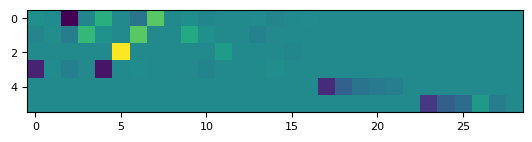

In [ ]:
# plot this matrix
from matplotlib import pyplot as plt
plt.imshow(contraction_mat_atomwise, cmap='viridis')

As you can see, the matrices are very different. That is, the model has no idea how to predict the matrices!

This could be shocking considering that it has only been tasked with fitting 2 matrices, a super simple problem that any model would overfit without any trouble. Well, you must take into account two things:

- **The target matrix is random**, while **the model is designed to learn equivariant matrices!**. All operations are equivariant and therefore result into an equivariant predicted matrix. For example, symmetry determines that the scalar element for node blocks for points 0 and 2 (at the top-left and bottom-right corner of the matrix) must be exactly the same because the point are equivalent. The random matrix does not satisfy this condition so it is impossible to fit.

- **The model is limited by the input node features**, which only contain one scalar and one vector. The combination possibilities are very small. If you increase the node feats irreps to `0e + 2x1o` (i.e. add one extra vector) and modify the `get_environment_representation` to still satisfy symmetries you should see some elements that have no symmetry problems (e.g. the 4 scalar elements at the top-left corner of node block for point 1) get very close to the target matrix.

We could work very hard to make our fake environment and true matrix computing functions equivariant to see the model fit perfectly, but you will see this in other real-life examples in the tutorials. Also **it is nice to see how a random matrix can't be fitted by an equivariant model to understand the power of equivariant design**!